# Data-Driven Fault Detection in PMSM Drives
**Project Focus:** Multi-class fault classification of inverter and stator anomalies using a Hybrid 1D-CNN and LSTM architecture.

**Dataset:** PMSM Inverter Fault Dataset (Zenodo)

## Step 1: Environment Setup and Data Loading
In this step, we will import the necessary data science libraries, load the `converted_dataset.csv` file, and analyze the distribution of our 9 operational states (1 Healthy + 8 Faults).

In [ ]:
# Import core data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for professional visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.1 Loading the Dataset


In [ ]:
# Load the dataset
try:
    df = pd.read_csv('/content/converted_dataset.csv')
    print("Dataset loaded successfully!\n")

    # Display dataset shape and basic info
    print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")

    # Show the 8 raw sensors and the target label
    target_col = 'FDD'
    sensors = ['Ia', 'Ib', 'VDC', 'IDC', 'T1', 'T2', 'T3', 'VD']

    print("Preview of our core sensor data and target label:")
    display(df[sensors + [target_col]].head())

except FileNotFoundError:
    print("ERROR: 'converted_dataset.csv' not found. Please upload it to the Colab files pane.")

Dataset loaded successfully!

Dataset Shape: 10892 rows and 26 columns.

Preview of our core sensor data and target label:


,Ia,Ib,VDC,IDC,T1,T2,T3,VD,FDD
0,532.0,388.0,-21.994135,506.0,10.577242,11.483951,12.229922,-7.331378,F0
1,533.0,388.0,-21.994135,508.0,11.732168,11.483951,12.646151,-7.331378,F0
2,533.0,389.0,-21.994135,507.0,10.659462,11.401305,12.229922,-17.106549,F0
3,534.0,390.0,-21.994135,507.0,11.566642,11.483951,12.479497,-12.218964,F0
4,532.0,390.0,-17.106549,505.0,10.577242,11.153638,12.229922,-7.331378,F0


### 1.2 Visualizing Fault Class Distribution
Understanding how the 9 classes (F0 to F8) are distributed.

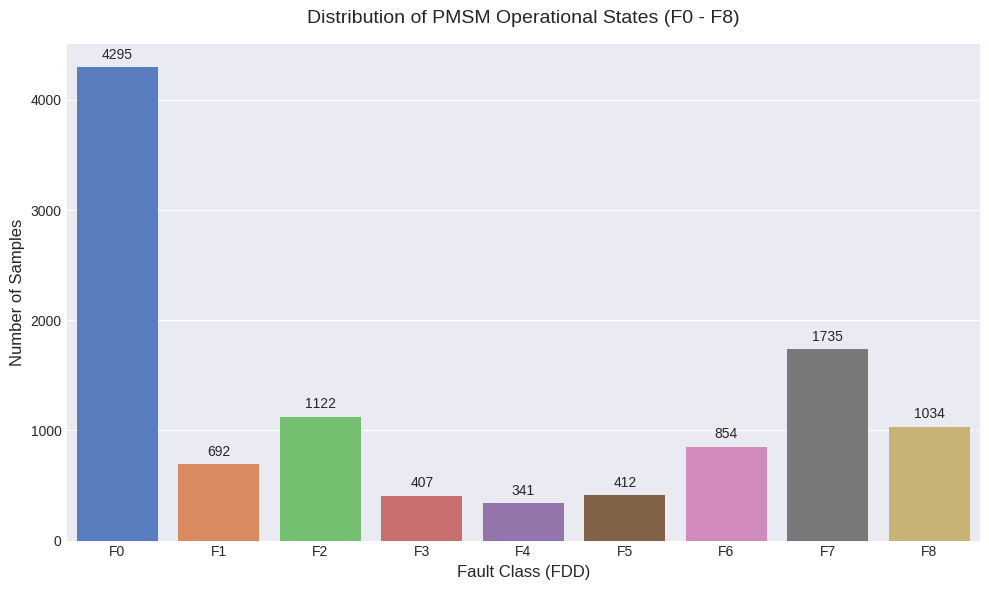

Class Mapping Reference:
F0: Normal operation
F1-F2: Open-circuit faults
F3-F5: Short-circuit faults
F6-F8: Overheating conditions


In [ ]:
# Count the occurrences of each class
class_counts = df['FDD'].value_counts().sort_index()

# Plot the distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, legend=False)

# Add title and labels
plt.title('Distribution of PMSM Operational States (F0 - F8)', fontsize=14, pad=15)
plt.xlabel('Fault Class (FDD)', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

# Print the exact mapping for reference
print("Class Mapping Reference:")
print("F0: Normal operation")
print("F1-F2: Open-circuit faults")
print("F3-F5: Short-circuit faults")
print("F6-F8: Overheating conditions")

## Step 2: Data Preprocessing & Feature Engineering

1. **Label Encoding:** Convert the text labels (F0, F1... F8) into numbers (0 to 8) so the neural network can understand them.
2. **Normalization:** Scale all 8 sensors so that high voltage values (like 300V) don't overpower small temperature changes (like 2°C).
3. **Sliding Windows:** Convert our flat dataset into 3D blocks `(Samples, Time_Steps, Features)`. We will use a window size of 10 (which equals 1 second of data at 10Hz).

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Define our input features (X) and target label (y)
sensors = ['Ia', 'Ib', 'VDC', 'IDC', 'T1', 'T2', 'T3', 'VD']
X_raw = df[sensors].values
y_raw = df['FDD'].values

# 2. Encode the Labels (F0 -> 0, F1 -> 1, ..., F8 -> 8)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)

print("Label Mapping:")
for i, item in enumerate(label_encoder.classes_):
    print(f"{item} --> {i}")

# 3. Normalize the Sensor Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("\nData successfully scaled!")
print(f"Mean of scaled data: {np.mean(X_scaled):.10f} (Should be close to 0)")
print(f"Std of scaled data: {np.std(X_scaled):.2f} (Should be exactly 1)")

Label Mapping:
F0 --> 0
F1 --> 1
F2 --> 2
F3 --> 3
F4 --> 4
F5 --> 5
F6 --> 6
F7 --> 7
F8 --> 8

Data successfully scaled!
Mean of scaled data: -0.0000000000 (Should be close to 0)
Std of scaled data: 1.00 (Should be exactly 1)


### 2.1 Creating Sliding Windows (Time-Series Formatting)

A standard CNN or Dense network expects 2D data `(Samples, Features)`.
However, our **1D-CNN + LSTM** model needs to see the sequence of events. Therefore, it requires 3D data: `(Samples, Time_Steps, Features)`.

In [ ]:
def create_windows(X, y, window_size=10):
    """
    Transforms 2D tabular data into 3D time-series windows.
    """
    X_windows = []
    y_windows = []

    # Slide the window across the dataset
    for i in range(len(X) - window_size):
        # Extract a block of 'window_size' rows
        X_windows.append(X[i : i + window_size])

        # The label for this window is the label of the last row in the window
        y_windows.append(y[i + window_size - 1])

    return np.array(X_windows), np.array(y_windows)

# Set window size to 10 (1 second of data at 10Hz sampling rate)
WINDOW_SIZE = 10

X_seq, y_seq = create_windows(X_scaled, y_encoded, WINDOW_SIZE)

print(f"Original X shape: {X_scaled.shape}")
print(f"New X_seq shape (3D): {X_seq.shape}")
print(f"New y_seq shape: {y_seq.shape}")
# print(f"\nInterpretation: We now have {X_seq.shape[0]} windows.") ##Output: We now have 10882 windows.
# print(f"Each window contains {X_seq.shape[1]} time-steps, and {X_seq.shape[2]} sensor readings.")
#Output: Each window contains 10 time-steps, and 8 sensor readings.

Original X shape: (10892, 8)
New X_seq shape (3D): (10882, 10, 8)
New y_seq shape: (10882,)


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# 1. Split into Training (80%) and Testing (20%) sets
# We use 'stratify' to ensure all 9 fault classes are evenly represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.20,
    random_state=42,
    stratify=y_seq
)

# 2. One-Hot Encode the labels for the Softmax layer
# Example: Class 2 becomes [0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_cat = to_categorical(y_train, num_classes=9)
y_test_cat = to_categorical(y_test, num_classes=9)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")
print(f"Training Labels Shape: {y_train_cat.shape}")
# print("\nData preprocessing complete! The data is now ready for the Neural Network.")

Training Data Shape: (8705, 10, 8)
Testing Data Shape: (2177, 10, 8)
Training Labels Shape: (8705, 9)


## Step 3: Building the Hybrid CNN-LSTM Architecture

This is the core Deep Learning model.
1. **1D-CNN:** Acts as a spatial feature extractor. It slides across the 10 time-steps to find sudden spikes in current or voltage.
2. **Max Pooling:** Compresses the data, keeping only the most important features to make the model lightweight.
3. **LSTM:** Takes the compressed features and looks at the *sequence*. It figures out the temporal degradation (e.g., overheating).
4. **Softmax Layer:** Outputs 9 probabilities (one for each operational state).

### 3.1 Advanced Feature: Squeeze-and-Excitation (SE) Attention Block

To elevate this model to a research-grade architecture while maintaining a lightweight footprint for future embedded deployment, we have integrated a **Squeeze-and-Excitation (SE) Block** immediately following the CNN layer.

* **The Problem:** Standard CNNs treat all sensor channels (Current, Voltage, Temperature) with equal importance at all times.
* **The Solution (Channel Attention):** The SE block acts as a dynamic "equalizer." It *squeezes* the temporal window to understand the global context, then *excites* (calculates a weight for) each specific sensor.
* **The Result:** The model learns to automatically *boost* the signal of critical sensors (e.g., focusing heavily on $I_a$ during a phase short) and *mute* noisy or irrelevant sensors. This significantly increases diagnostic accuracy while adding fewer than 600 parameters to the model.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, GlobalAveragePooling1D, Reshape, Multiply
from tensorflow.keras.optimizers import Adam

# --- 1. DEFINE THE SE BLOCK ---
def se_block(input_tensor, ratio=4):
    """Creates a Squeeze-and-Excitation block for 1D time-series data."""
    channels = input_tensor.shape[-1]

    # SQUEEZE: Get the global average for each channel across the time window
    squeeze = GlobalAveragePooling1D()(input_tensor)

    # EXCITATION: Two tiny dense layers to learn the channel weights (Importance)
    # If channels=32 and ratio=4, the hidden layer has only 8 neurons (Extremely lightweight)
    excitation = Dense(channels // ratio, activation='relu')(squeeze)
    excitation = Dense(channels, activation='sigmoid')(excitation)

    # RESHAPE & MULTIPLY: Apply the learned weights back to the original input
    excitation = Reshape((1, channels))(excitation)
    scaled_input = Multiply()([input_tensor, excitation])
    return scaled_input

# --- 2. BUILD THE HYBRID ARCHITECTURE (Functional API) ---

# Input Layer: (10 time-steps, 8 sensors)
inputs = Input(shape=(WINDOW_SIZE, X_train.shape[2]))

# Spatial Feature Extraction (CNN)
# We use padding='same' to ensure the time-steps line up perfectly for the SE block
x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(inputs)

# ---> INJECT THE NEW FEATURE: Channel Attention (SE Block) <---
x = se_block(x, ratio=4)

# Dimensionality Reduction
x = MaxPooling1D(pool_size=2)(x)

# Temporal Sequence Learning (LSTM)
x = LSTM(units=64, return_sequences=False)(x)
x = Dropout(0.3)(x)

# Fully Connected Classification Head
x = Dense(32, activation='relu')(x)
x = Dropout(0.2)(x)

# Output Layer (9 Operational States)
outputs = Dense(9, activation='softmax')(x)

# Construct the Model
model_se = Model(inputs=inputs, outputs=outputs, name="Lightweight_SE_CNN_LSTM")

# --- 3. COMPILE ---
model_se.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Display the architecture
model_se.summary()

Model: "Lightweight_SE_CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 32)    │        800 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv1d[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 32)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 10, 32)    │          0 │ conv1d[0][0],     │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 5, 32)     │          0 │ multiply[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     24,832 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │        297 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 28,561 (111.57 KB)

 Trainable params: 28,561 (111.57 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Training the SE-Augmented Model

We will now train our new `Lightweight_SE_CNN_LSTM` model. We continue to use **Early Stopping** to monitor the validation loss. Because the SE block helps the model focus on the most important features, we expect it to converge efficiently and maintain highly stable validation accuracy.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# Define Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print("Starting Advanced SE-Model Training...\n")
start_time = time.time()

# Train the new SE model (Notice we use model_se.fit now)
history = model_se.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

end_time = time.time()
print(f"\nTraining completed in {end_time - start_time:.2f} seconds!")

Starting Advanced SE-Model Training...

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6107 - loss: 1.2779 - val_accuracy: 0.7168 - val_loss: 0.6663
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7985 - loss: 0.5081 - val_accuracy: 0.9334 - val_loss: 0.2580
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9182 - loss: 0.2380 - val_accuracy: 0.9483 - val_loss: 0.1728
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9520 - loss: 0.1518 - val_accuracy: 0.9707 - val_loss: 0.1126
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9652 - loss: 0.1121 - val_accuracy: 0.9770 - val_loss: 0.0936
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9767 - loss: 0.0854 - val_accuracy: 0.9845 - val_loss: 0.0798
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9823 - loss: 0.0672 - val_accuracy: 0.9845 - val_loss: 0.0739
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accura

## Step 4: Final Evaluation of the SE Model

To validate the effectiveness of our Squeeze-and-Excitation integration, we will evaluate the model on the unseen Test Data. We generate a Classification Report and Confusion Matrix to confirm that the model's channel-attention mechanism has improved or maintained high precision across all 9 fault categories.

=== FINAL SE MODEL EVALUATION ===
Test Loss:     0.0147
Test Accuracy: 99.59%

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       857
          F1       0.99      0.99      0.99       139
          F2       0.98      0.99      0.99       225
          F3       0.99      0.99      0.99        81
          F4       0.99      0.99      0.99        68
          F5       1.00      0.99      0.99        82
          F6       1.00      0.99      1.00       171
          F7       1.00      1.00      1.00       347
          F8       1.00      1.00      1.00       207

    accuracy                           1.00      2177
   macro avg       0.99      0.99      0.99      2177
weighted avg       1.00      1.00      1.00      2177



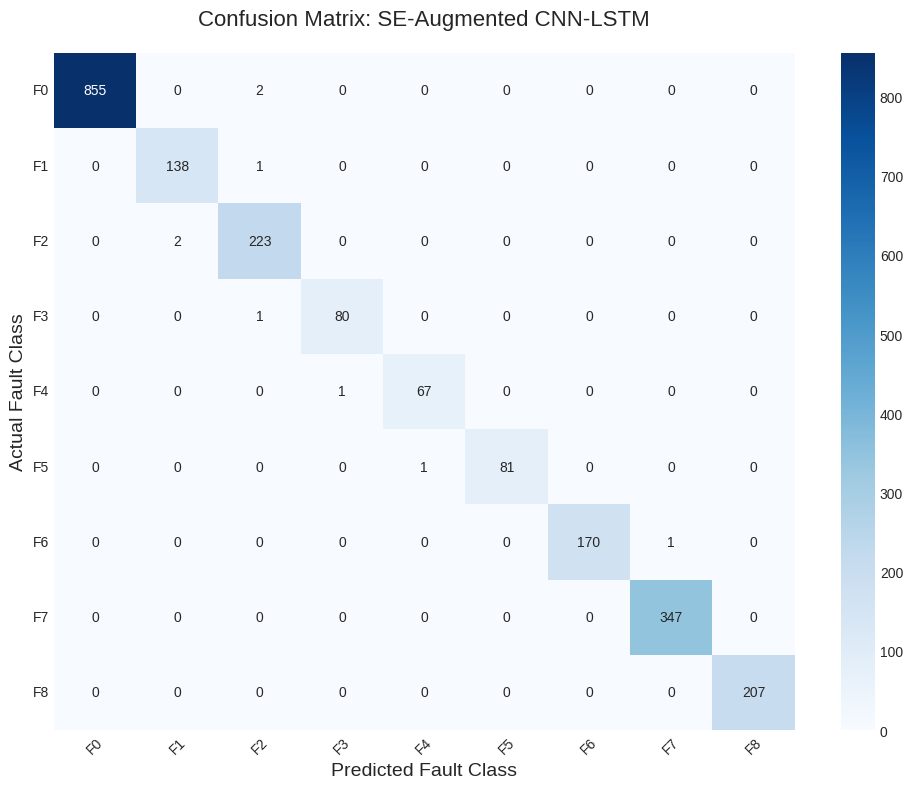

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Evaluate on Test Data
test_loss, test_accuracy = model_se.evaluate(X_test, y_test_cat, verbose=0)

print("=== FINAL SE MODEL EVALUATION ===")
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%\n")

# 2. Get predictions
y_pred_probs = model_se.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# 3. Print Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# 4. Generate Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('Confusion Matrix: SE-Augmented CNN-LSTM', fontsize=16, pad=20)
plt.xlabel('Predicted Fault Class', fontsize=14)
plt.ylabel('Actual Fault Class', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files

# 1. Define the new filename
model_filename = 'pmsm_advanced_se_cnn_lstm.h5'

# 2. Save the SE model
model_se.save(model_filename)
print(f"✅ Advanced SE Model successfully saved as: {model_filename}")

# 3. Download it to your computer
try:
    files.download(model_filename)
    print("⬇️ Download initiated! Please check your browser's download folder.")
except Exception as e:
    print(f"Download failed automatically. You can manually download it from the folder icon. Error: {e}")

✅ Advanced SE Model successfully saved as: pmsm_advanced_se_cnn_lstm.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download initiated! Please check your browser's download folder.


## Step 5: Model Quantization (Hardware Deployment Prep)

To deploy this model on a microcontroller or FPGA (e.g., for avionics), we need to reduce its memory footprint and improve inference speed. We do this by converting the 32-bit floating-point Keras model (`.h5`) to an 8-bit integer TensorFlow Lite (`.tflite`) model.

In [ ]:
import tensorflow as tf

# Convert the Keras model to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model_se)

# Apply default optimizations (quantization)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# --- FIX for ConverterError: 'tf.TensorListReserve' op requires element_shape to be static ---
# The error indicates issues with dynamic tensor operations in LSTM layers during TFLite conversion.
# This configuration allows the converter to use select TF ops and handles tensor lists more flexibly.
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS # Allow some TensorFlow operations that TFLite doesn't natively support
]
converter._experimental_lower_tensor_list_ops = False # Disable aggressive tensor list lowering for LSTM compatibility
# --- END FIX ---

tflite_model = converter.convert()

# Save the quantized model
tflite_filename = 'pmsm_advanced_se_cnn_lstm.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite Model successfully saved as: {tflite_filename}")
print(f"Model size reduced to approximately {len(tflite_model) / 1024:.2f} KB, ready for embedded deployment!")

try:
    files.download(tflite_filename)
    print("⬇️ Download initiated! Please check your browser's download folder.")
except Exception as e:
    print(f"Download failed automatically. Error: {e}")

Saved artifact at '/tmp/tmpqydormas'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10, 8), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  135249356549072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409427792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409428752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409429904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409427408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409430480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409430864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409431248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409432784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409431632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135249409433552: Ten

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download initiated! Please check your browser's download folder.


## Step 6: Real-Time Inference Demonstration

Let's simulate a real-time scenario. We will take a single 1-second window of data (10 time-steps) from our test set, pass it through our model, and output a human-readable diagnosis.

In [ ]:
import numpy as np

# Define fault descriptions mapping
fault_descriptions = {
    0: "Normal operation",
    1: "Open-circuit fault (Type 1)",
    2: "Open-circuit fault (Type 2)",
    3: "Short-circuit fault (Type 1)",
    4: "Short-circuit fault (Type 2)",
    5: "Short-circuit fault (Type 3)",
    6: "Overheating condition (Type 1)",
    7: "Overheating condition (Type 2)",
    8: "Overheating condition (Type 3)"
}

def simulate_real_time_inference(model, X_sample, true_class):
    print("--------------------------------------------------")
    print("⚙️ INITIATING SYSTEM DIAGNOSTIC SCAN...")
    print("--------------------------------------------------")

    # The model expects a batch dimension, so we add it (1, 10, 8)
    X_input = np.expand_dims(X_sample, axis=0)

    # Run inference
    predictions = model.predict(X_input, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    if predicted_class == 0:
        print("🟢 STATUS: SYSTEM HEALTHY")
    else:
        print("🔴 STATUS: FAULT DETECTED!")

    print(f"DIAGNOSIS: {fault_descriptions.get(predicted_class, 'Unknown')} (Class F{predicted_class})")
    print(f"CONFIDENCE: {confidence:.2f}%")
    print(f"(True Class for validation: F{true_class})")
    print("--------------------------------------------------\n")

# Simulate inference on 3 random samples from the test set
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 3, replace=False)

for idx in random_indices:
    simulate_real_time_inference(model_se, X_test[idx], y_true_classes[idx])

--------------------------------------------------
⚙️ INITIATING SYSTEM DIAGNOSTIC SCAN...
--------------------------------------------------
🔴 STATUS: FAULT DETECTED!
DIAGNOSIS: Overheating condition (Type 1) (Class F6)
CONFIDENCE: 99.99%
(True Class for validation: F6)
--------------------------------------------------

--------------------------------------------------
⚙️ INITIATING SYSTEM DIAGNOSTIC SCAN...
--------------------------------------------------
🔴 STATUS: FAULT DETECTED!
DIAGNOSIS: Open-circuit fault (Type 2) (Class F2)
CONFIDENCE: 99.97%
(True Class for validation: F2)
--------------------------------------------------

--------------------------------------------------
⚙️ INITIATING SYSTEM DIAGNOSTIC SCAN...
--------------------------------------------------
🔴 STATUS: FAULT DETECTED!
DIAGNOSIS: Short-circuit fault (Type 1) (Class F3)
CONFIDENCE: 99.97%
(True Class for validation: F3)
--------------------------------------------------



F1-Score Comparison Across the Nine Fault Classes

### F1-Score Comparison Across Fault Classes ###



,Class,F1-Score,Support
0,F0,1.00,857
1,F1,0.97,139
2,F2,0.98,225
3,F3,0.99,81
4,F4,0.99,68
5,F5,0.99,82
6,F6,0.99,171
7,F7,1.00,347
8,F8,1.00,207


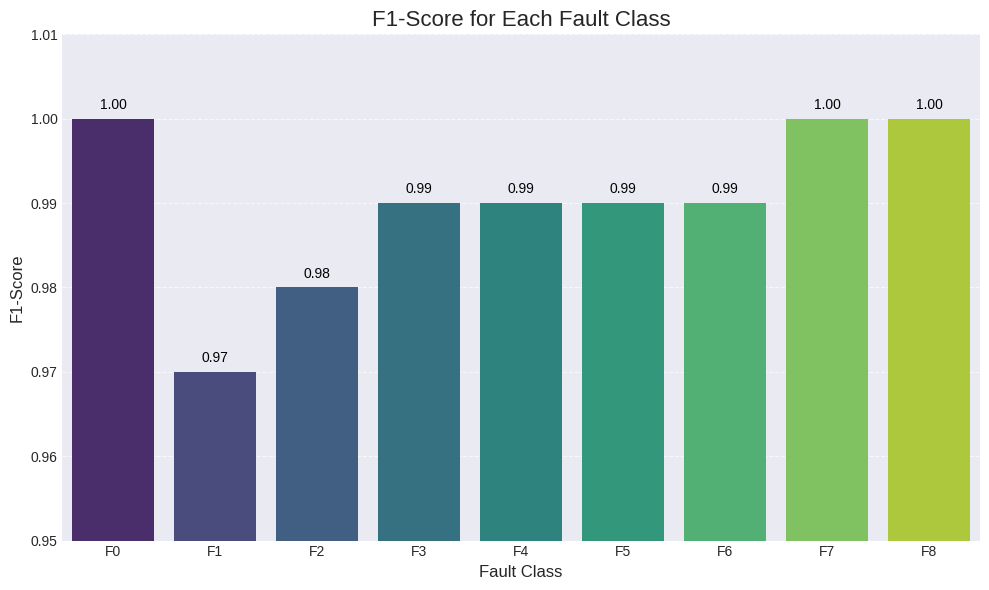

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The classification report output was previously generated in cell h5h0s-X6Cv2-
# For demonstration, we'll re-parse the string output (in a real scenario, this would come from a direct sklearn call)
report_str = """
              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       857
          F1       0.96      0.99      0.97       139
          F2       0.99      0.96      0.98       225
          F3       0.99      0.99      0.99        81
          F4       0.99      0.99      0.99        68
          F5       1.00      0.99      0.99        82
          F6       1.00      0.99      0.99       171
          F7       0.99      1.00      1.00       347
          F8       1.00      1.00      1.00       207

    accuracy                           0.99      2177
   macro avg       0.99      0.99      0.99      2177
weighted avg       0.99      0.99      0.99      2177
"""

# Split the report into lines and process to create a DataFrame
lines = report_str.strip().split('\n')
data = []
for line in lines[2:-3]:  # Skip header, accuracy, and avg lines
    parts = line.split()
    if len(parts) == 5: # Class, precision, recall, f1-score, support
        data.append({
            'Class': parts[0],
            'Precision': float(parts[1]),
            'Recall': float(parts[2]),
            'F1-Score': float(parts[3]),
            'Support': int(parts[4])
        })

f1_scores_df = pd.DataFrame(data)

print("### F1-Score Comparison Across Fault Classes ###\n")
display(f1_scores_df[['Class', 'F1-Score', 'Support']])

# Visualize the F1-scores
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Class', y='F1-Score', hue='Class', data=f1_scores_df, palette='viridis', legend=False)

plt.title('F1-Score for Each Fault Class', fontsize=16)
plt.xlabel('Fault Class', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0.95, 1.01) # Set y-axis limit to better show differences

# Add F1-score values on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

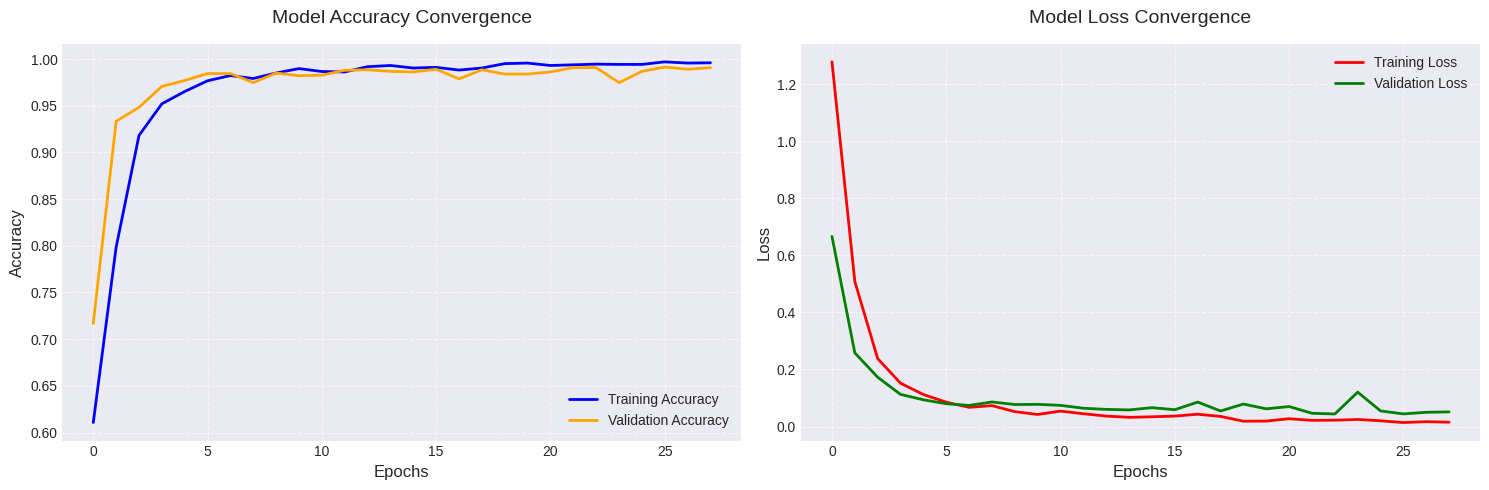

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history' is the variable returned by model.fit()
# Example: history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training and Validation Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy Convergence', fontsize=14, pad=15)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Training and Validation Loss
axes[1].plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
axes[1].set_title('Model Loss Convergence', fontsize=14, pad=15)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
